# FOLLOWER Static Cost calculation

In [16]:
import numpy as np
from pathlib import Path

DOMAIN = 'game'
MAP = 'brc202d.map'
WALLS = ['T', '@']
maps_path = Path(f'../example_problems/{DOMAIN}.domain/maps/')
map_path = maps_path / MAP

In [17]:
with map_path.open() as f:
    lines = f.readlines()
lines = [line.strip() for line in lines if line.strip()]
lines = lines[4:] # ignore headers

map_ = np.array([list(line) for line in lines])
map_ = np.where(np.isin(map_, WALLS), 1, 0).astype(np.bool)

In [18]:
costs = np.zeros_like(map_, dtype=np.float32)
avg_costs = np.zeros_like(map_, dtype=np.float32)

In [19]:
map_.sum()

np.int64(211779)

In [20]:
eval_cells = np.vstack(np.where(map_ == 0)).T

In [21]:
from tqdm.auto import tqdm
from collections import deque

# iterate over the map and use bfs to the avg cost for all tiles
def compute_static_cost(map_):

    loop = tqdm(total=len(eval_cells))
    for i, j in eval_cells:
        # bfs
        v_free = 0 # vertices reachable from the current vertex
        paths_cost = np.zeros_like(map_, dtype=np.uint16)
        queue = deque([(i, j)])
        visited = np.zeros_like(map_, dtype=np.bool)
        while queue:
            y, x = queue.popleft()
            src_cost = paths_cost[y, x]
            v_free += 1
            visited[y, x] = True
            for dy, dx in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                ny, nx = y + dy, x + dx
                within_x = 0 <= nx < map_.shape[1]
                within_y = 0 <= ny < map_.shape[0]
                if not within_x or not within_y:
                    continue
                not_wall = map_[ny, nx] == 0
                not_visited = not visited[ny, nx]
                not_queued = (ny, nx) not in queue
                if not_wall and not_visited and not_queued:
                    paths_cost[ny, nx] = src_cost + 1
                    queue.append((ny, nx))

        avg_cost = np.sum(paths_cost) / v_free
        avg_costs[i, j] = avg_cost
        loop.update(1)

    return avg_costs.max()/avg_costs

# cost_st = compute_static_cost(map_)

In [22]:
from tqdm.auto import tqdm
from collections import deque
import numpy as np

def compute_static_cost(map_):
    eval_cells = [(i, j) for i in range(map_.shape[0]) for j in range(map_.shape[1]) if map_[i, j] == 0]
    avg_costs = np.zeros_like(map_, dtype=np.float32)
    visited = np.zeros_like(map_, dtype=bool)
    loop = tqdm(total=len(eval_cells), desc="Computing Static Costs")
    
    for i, j in eval_cells:
        # Initialize BFS
        v_free = 0  # Number of reachable vertices
        queue = deque([(i, j)])
        visited.fill(False)
        visited[i, j] = True
        paths_cost = np.zeros_like(map_, dtype=np.uint16)
        
        while queue:
            y, x = queue.popleft()
            src_cost = paths_cost[y, x]
            v_free += 1
            
            # Explore neighbors
            for dy, dx in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < map_.shape[0] and 0 <= nx < map_.shape[1] and not visited[ny, nx]:
                    if map_[ny, nx] == 0:  # Free tile
                        visited[ny, nx] = True
                        paths_cost[ny, nx] = src_cost + 1
                        queue.append((ny, nx))
        
        # Compute average cost for the current tile
        avg_costs[i, j] = np.sum(paths_cost[paths_cost > 0]) / v_free if v_free > 0 else 0
        loop.update(1)
    
    loop.close()
    return avg_costs.max() / avg_costs

# Example usage
# map_ = np.array([[...], [...], ...])  # Define your map here
cost_st = compute_static_cost(map_)


Computing Static Costs: 100%|██████████| 43151/43151 [1:15:52<00:00,  9.48it/s]
/var/folders/qh/sy5h09nx3_v6d1tr04hgnnbr0000gn/T/ipykernel_17942/2029616465.py:38: RuntimeWarning: divide by zero encountered in divide
  return avg_costs.max() / avg_costs


In [23]:
cost_st

array([[inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       ...,
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf]], dtype=float32)

In [24]:
cost_st * (1 - map_)

/var/folders/qh/sy5h09nx3_v6d1tr04hgnnbr0000gn/T/ipykernel_17942/3821712336.py:1: RuntimeWarning: invalid value encountered in multiply
  cost_st * (1 - map_)


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [25]:
filtered_costs = np.nan_to_num(cost_st, nan=0, posinf=0, neginf=0) * (1 - map_)
filtered_costs = np.clip(filtered_costs, 0, np.quantile(filtered_costs, 0.99))

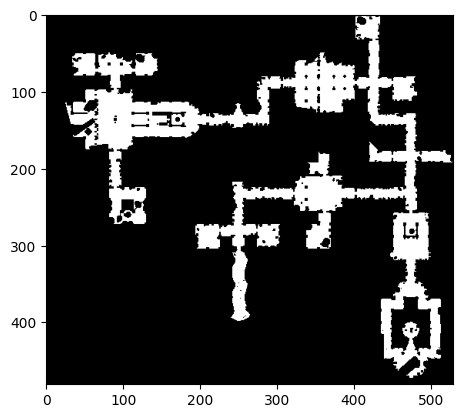

In [26]:
import matplotlib.pyplot as plt

plt.imshow(1 - map_, cmap='gray')

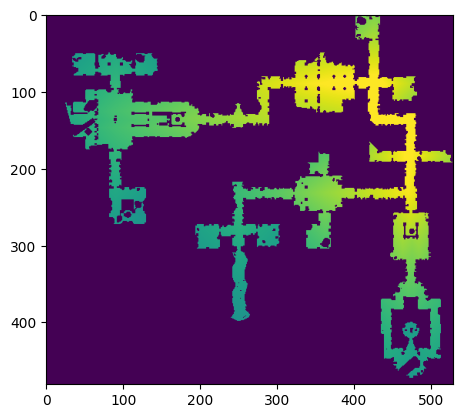

In [27]:
plt.imshow(filtered_costs)

In [28]:
out_file = Path(f'../example_problems/{DOMAIN}.domain/maps/{MAP}_costs.npy')
np.save(out_file, cost_st)